# 60 - K-Means e inspecao qualitativa dos clusters

Este notebook executa a camada de clusterizacao com K-Means sobre a representacao TF-IDF baseline definida no notebook 50. A unidade de analise continua sendo uma `descricao_normalizada` unica, com `frequencia` preservada para dimensionar a importancia pratica de cada cluster.

As importacoes abaixo combinam as funcoes reutilizaveis do pacote com metricas consolidadas do `scikit-learn`. O notebook concentra a narrativa experimental, a escolha de `k` e a preparacao dos artefatos para revisao humana.

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.metrics.pairwise import euclidean_distances

from nofis_classifier.datasets import (
    DEFAULT_PERIOD_LABEL,
    FILTERED_MARKET_DATASET_NAME,
    load_processed_items,
    prepare_modeling_items,
    processed_dataset_path,
)
from nofis_classifier.experiments import append_experiment_records, create_experiment_record
from nofis_classifier.paths import find_project_root
from nofis_classifier.schema import DESCRIPTION_EXAMPLE, DESCRIPTION_NORMALIZED, FREQUENCY
from nofis_classifier.tfidf import (
    BASELINE_TFIDF_CONFIG_NAME,
    TfidfExperimentConfig,
    default_tfidf_configs,
    fit_tfidf_experiment,
)

pd.set_option("display.max_colwidth", 160)

Esta celula controla se o notebook roda como simulacao rapida ou como experimento completo. A simulacao reduz primeiro a quantidade de descricoes e depois limita o numero de features TF-IDF, mantendo o fluxo metodologico igual.

In [19]:
RUN_SIMULATION = True
SIMULATION_DESCRIPTION_COUNT = 1_000
SIMULATION_MAX_FEATURES = 5_000
SIMULATION_K_VALUES = [5, 10, 15, 20, 25, 30]
BASELINE_TFIDF_CONFIG_NAME = "word_unigram_min_df_2"

RANDOM_STATE = 42

Aqui sao definidos os caminhos do experimento. A entrada e o Parquet processado filtrado; as saidas ficam em `reports/kmeans/`, separadas dos relatorios de TF-IDF.

In [20]:
PROJECT_ROOT = find_project_root()
DATASET_PATH = processed_dataset_path(
    dataset_name=FILTERED_MARKET_DATASET_NAME,
    period_label=DEFAULT_PERIOD_LABEL,
    root=PROJECT_ROOT,
)
REPORT_DIR = PROJECT_ROOT / "reports" / "kmeans"

DATASET_PATH

WindowsPath('C:/Users/samue/Scripts/Nofis-Classifier/data/processed/items-notas-fiscais-filtros-combinados/items-notas-fiscais-filtros-combinados-202501-202504.parquet')

## Carregar base e recomputar TF-IDF baseline

O notebook recomputa o TF-IDF baseline em vez de depender de estado em memoria do notebook 50. Isso deixa a clusterizacao reproduzivel a partir dos dados processados e da configuracao versionada.

In [21]:
raw_items = load_processed_items(DATASET_PATH)
modeling_items = prepare_modeling_items(raw_items)

if RUN_SIMULATION:
    simulation_count = min(SIMULATION_DESCRIPTION_COUNT, len(modeling_items))
    modeling_items = (
        modeling_items.sample(n=simulation_count, random_state=RANDOM_STATE)
        .sort_values(DESCRIPTION_NORMALIZED)
        .reset_index(drop=True)
    )
    modeling_items["descricao_id"] = np.arange(len(modeling_items), dtype=np.int64)

baseline_config = next(config for config in default_tfidf_configs() if config.name == BASELINE_TFIDF_CONFIG_NAME)
if RUN_SIMULATION:
    baseline_config = TfidfExperimentConfig(
        name=f"{BASELINE_TFIDF_CONFIG_NAME}_simulation_max_features_{SIMULATION_MAX_FEATURES}",
        analyzer=baseline_config.analyzer,
        ngram_range=baseline_config.ngram_range,
        min_df=baseline_config.min_df,
        max_features=SIMULATION_MAX_FEATURES,
        max_df=baseline_config.max_df,
        sublinear_tf=baseline_config.sublinear_tf,
        norm=baseline_config.norm,
    )

vectorizer, tfidf_matrix = fit_tfidf_experiment(modeling_items[DESCRIPTION_NORMALIZED], baseline_config)

assert tfidf_matrix.shape[0] == len(modeling_items)
if RUN_SIMULATION:
    assert len(modeling_items) <= SIMULATION_DESCRIPTION_COUNT
    assert tfidf_matrix.shape[1] <= SIMULATION_MAX_FEATURES

display(
    pd.DataFrame(
        {
            "modo_simulacao": [RUN_SIMULATION],
            "descricoes_unicas": [len(modeling_items)],
            "frequencia_total": [int(modeling_items[FREQUENCY].sum())],
            "tfidf_features": [tfidf_matrix.shape[1]],
            "config_tfidf": [baseline_config.name],
        }
    )
)
display(modeling_items.head())

,modo_simulacao,descricoes_unicas,frequencia_total,tfidf_features,config_tfidf
0,True,1000,4306,742,word_unigram_min_df_2_simulation_max_features_5000


,descricao_id,descricao_normalizada,frequencia,descricao_original_exemplo,descricoes_originais_distintas,primeiro_mes,ultimo_mes,meses_presentes,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente
0,0,000 maca vermelha importada kg,1,000-MACA VERMELHA IMPORTADA KG,1,2025-02,2025-02,1,8081000.0,Maçãs frescas
1,1,00000000000328 manga tommy,1,00000000000328 MANGA TOMMY,1,2025-04,2025-04,1,8045020.0,Mangas frescas ou secas
2,2,00000000000610 alho poro,1,00000000000610 ALHO PORO,1,2025-04,2025-04,1,7039090.0,"Alhos-porros e outros produtos hortícolas aliáceos, frescos ou refrigerados, exceto para semeadura"
3,3,07891242010413 cera pasta ingleza amarela 400g,1,07891242010413 CERA PASTA INGLEZA AMARELA 400G,1,2025-03,2025-03,1,34052000.0,"Encáusticas e preparações semelhantes, para conservação e limpeza de móveis de madeira, soalhos e de outros artigos de madeira"
4,4,12961 lampada pingo dagua 5w,1,12961 LAMPADA PINGO DAGUA 5W,1,2025-02,2025-02,1,85392910.0,"Outras lâmpadas/tubos incandescentes, para uma tensão inferior ou igual a 15 V"


## Executar K-Means para varios valores de k

A grade inicial testa `10, 15, 20, 25, 30` e depois amplia para `20` a `100`, limitada pelo volume de descricoes. As metricas apoiam a decisao, mas a escolha final de `k` deve tambem considerar interpretabilidade.

In [22]:
if RUN_SIMULATION:
    candidate_k_values = SIMULATION_K_VALUES
else:
    initial_k_values = [10, 15, 20, 25, 30]
    wide_k_values = list(range(20, 101, 10))
    candidate_k_values = initial_k_values + wide_k_values

K_VALUES = sorted({k for k in candidate_k_values if 2 <= k < len(modeling_items)})

SAMPLE_SIZE = len(modeling_items) if RUN_SIMULATION else min(5_000, len(modeling_items))
rng = np.random.default_rng(RANDOM_STATE)
sample_indexes = np.sort(rng.choice(len(modeling_items), size=SAMPLE_SIZE, replace=False))
sample_matrix = tfidf_matrix[sample_indexes]

K_VALUES, SAMPLE_SIZE

([5, 10, 15, 20, 25, 30], 1000)

A celula seguinte ajusta um K-Means para cada `k`. A inercia usa a base completa; Silhouette, Calinski-Harabasz e Davies-Bouldin usam uma amostra fixa para manter o tempo de execucao controlado.

In [23]:
metric_records = []
models_by_k = {}
labels_by_k = {}
sample_dense = sample_matrix.toarray()

for k in K_VALUES:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(tfidf_matrix)
    sample_labels = labels[sample_indexes]

    metric_records.append(
        {
            "config_name": f"{baseline_config.name}_k_{k}",
            "tfidf_config_name": baseline_config.name,
            "simulation": RUN_SIMULATION,
            "k": k,
            "document_count": tfidf_matrix.shape[0],
            "feature_count": tfidf_matrix.shape[1],
            "sample_size": SAMPLE_SIZE,
            "inertia": float(model.inertia_),
            "silhouette_cosine_sample": float(silhouette_score(sample_matrix, sample_labels, metric="cosine")),
            "calinski_harabasz_sample": float(calinski_harabasz_score(sample_dense, sample_labels)),
            "davies_bouldin_sample": float(davies_bouldin_score(sample_dense, sample_labels)),
            "min_cluster_size": int(pd.Series(labels).value_counts().min()),
            "max_cluster_size": int(pd.Series(labels).value_counts().max()),
        }
    )
    models_by_k[k] = model
    labels_by_k[k] = labels

metrics = pd.DataFrame.from_records(metric_records)
metrics.sort_values("silhouette_cosine_sample", ascending=False)

,config_name,tfidf_config_name,simulation,k,document_count,feature_count,sample_size,inertia,silhouette_cosine_sample,calinski_harabasz_sample,davies_bouldin_sample,min_cluster_size,max_cluster_size
4,word_unigram_min_df_2_simulation_max_features_5000_k_25,word_unigram_min_df_2_simulation_max_features_5000,True,25,1000,742,1000,838.503093,0.075869,6.331521,3.649948,6,417
3,word_unigram_min_df_2_simulation_max_features_5000_k_20,word_unigram_min_df_2_simulation_max_features_5000,True,20,1000,742,1000,852.473181,0.071156,7.061727,3.773229,13,477
2,word_unigram_min_df_2_simulation_max_features_5000_k_15,word_unigram_min_df_2_simulation_max_features_5000,True,15,1000,742,1000,880.751689,0.054072,7.064417,3.913645,10,564
1,word_unigram_min_df_2_simulation_max_features_5000_k_10,word_unigram_min_df_2_simulation_max_features_5000,True,10,1000,742,1000,905.708486,0.038425,7.709483,4.168571,17,699
0,word_unigram_min_df_2_simulation_max_features_5000_k_5,word_unigram_min_df_2_simulation_max_features_5000,True,5,1000,742,1000,930.214146,0.029301,10.421567,4.523158,26,756
5,word_unigram_min_df_2_simulation_max_features_5000_k_30,word_unigram_min_df_2_simulation_max_features_5000,True,30,1000,742,1000,850.973056,0.027422,4.646475,2.289484,1,712


Os graficos abaixo ajudam a comparar tendencia de cotovelo e metricas internas. Eles nao substituem a leitura qualitativa dos clusters.

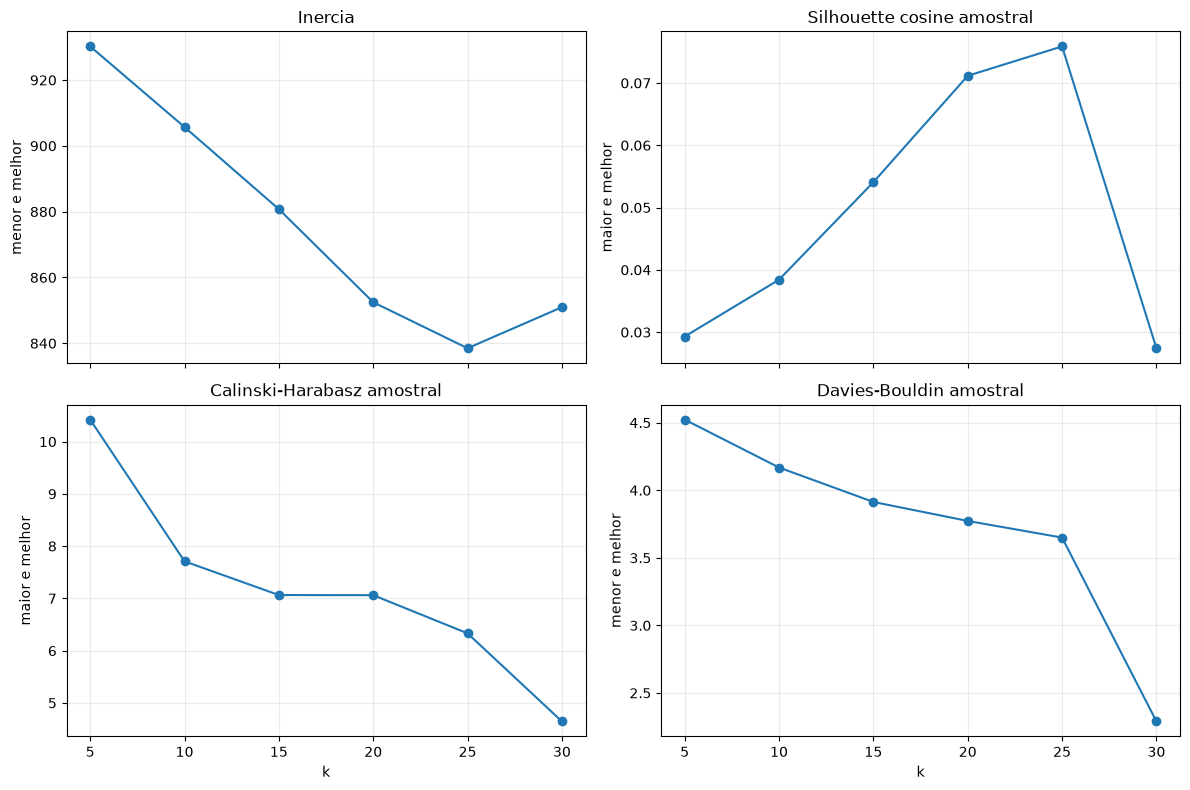

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0, 0].plot(metrics["k"], metrics["inertia"], marker="o")
axes[0, 0].set_title("Inercia")
axes[0, 0].set_ylabel("menor e melhor")

axes[0, 1].plot(metrics["k"], metrics["silhouette_cosine_sample"], marker="o")
axes[0, 1].set_title("Silhouette cosine amostral")
axes[0, 1].set_ylabel("maior e melhor")

axes[1, 0].plot(metrics["k"], metrics["calinski_harabasz_sample"], marker="o")
axes[1, 0].set_title("Calinski-Harabasz amostral")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("maior e melhor")

axes[1, 1].plot(metrics["k"], metrics["davies_bouldin_sample"], marker="o")
axes[1, 1].set_title("Davies-Bouldin amostral")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("menor e melhor")

for ax in axes.ravel():
    ax.grid(alpha=0.25)

plt.tight_layout()

## Escolher k inicial para inspecao

`BEST_K` e definido inicialmente pelo maior Silhouette amostral. Antes de consolidar o resultado no TCC, revise o relatorio qualitativo e ajuste manualmente este valor se outro `k` gerar clusters mais interpretaveis.

In [25]:
metric_ranked_k = int(metrics.sort_values("silhouette_cosine_sample", ascending=False).iloc[0]["k"])
BEST_K = metric_ranked_k

best_model = models_by_k[BEST_K]
best_labels = labels_by_k[BEST_K]

display(metrics[metrics["k"] == BEST_K])
BEST_K

,config_name,tfidf_config_name,simulation,k,document_count,feature_count,sample_size,inertia,silhouette_cosine_sample,calinski_harabasz_sample,davies_bouldin_sample,min_cluster_size,max_cluster_size
4,word_unigram_min_df_2_simulation_max_features_5000_k_25,word_unigram_min_df_2_simulation_max_features_5000,True,25,1000,742,1000,838.503093,0.075869,6.331521,3.649948,6,417


25

## Gerar inspecao qualitativa dos clusters

Para cada cluster, o relatorio reune termos mais relevantes, exemplos centrais, exemplos de borda, exemplos aleatorios, quantidade de descricoes unicas e frequencia total. As colunas `avaliacao_qualitativa`, `rotulo_humano` e `observacoes` ficam prontas para a revisao humana.

In [26]:
feature_names = np.asarray(vectorizer.get_feature_names_out())


def top_terms_for_cluster(cluster_id: int, n_terms: int = 15) -> str:
    centroid = best_model.cluster_centers_[cluster_id]
    top_indexes = np.argsort(centroid)[::-1][:n_terms]
    return " | ".join(feature_names[top_indexes])


def join_examples(frame: pd.DataFrame, n_examples: int = 6) -> str:
    return " | ".join(frame[DESCRIPTION_NORMALIZED].head(n_examples).astype(str))


clustered_items = modeling_items.copy()
clustered_items["cluster"] = best_labels
clustered_items["distancia_centroide"] = np.nan

for cluster_id in range(BEST_K):
    row_indexes = np.flatnonzero(best_labels == cluster_id)
    distances = euclidean_distances(tfidf_matrix[row_indexes], best_model.cluster_centers_[cluster_id].reshape(1, -1)).ravel()
    clustered_items.loc[row_indexes, "distancia_centroide"] = distances

clustered_items.head()

,descricao_id,descricao_normalizada,frequencia,descricao_original_exemplo,descricoes_originais_distintas,primeiro_mes,ultimo_mes,meses_presentes,codigo_ncm_mais_frequente,ncm_tipo_mais_frequente,cluster,distancia_centroide
0,0,000 maca vermelha importada kg,1,000-MACA VERMELHA IMPORTADA KG,1,2025-02,2025-02,1,8081000.0,Maçãs frescas,2,0.959181
1,1,00000000000328 manga tommy,1,00000000000328 MANGA TOMMY,1,2025-04,2025-04,1,8045020.0,Mangas frescas ou secas,8,1.001027
2,2,00000000000610 alho poro,1,00000000000610 ALHO PORO,1,2025-04,2025-04,1,7039090.0,"Alhos-porros e outros produtos hortícolas aliáceos, frescos ou refrigerados, exceto para semeadura",8,0.998274
3,3,07891242010413 cera pasta ingleza amarela 400g,1,07891242010413 CERA PASTA INGLEZA AMARELA 400G,1,2025-03,2025-03,1,34052000.0,"Encáusticas e preparações semelhantes, para conservação e limpeza de móveis de madeira, soalhos e de outros artigos de madeira",8,0.995042
4,4,12961 lampada pingo dagua 5w,1,12961 LAMPADA PINGO DAGUA 5W,1,2025-02,2025-02,1,85392910.0,"Outras lâmpadas/tubos incandescentes, para uma tensão inferior ou igual a 15 V",9,0.875601


In [27]:
cluster_records = []

for cluster_id in range(BEST_K):
    subset = clustered_items[clustered_items["cluster"] == cluster_id].copy()
    central = subset.sort_values("distancia_centroide", ascending=True)
    border = subset.sort_values("distancia_centroide", ascending=False)
    random_examples = subset.sample(n=min(6, len(subset)), random_state=RANDOM_STATE + cluster_id)

    cluster_records.append(
        {
            "cluster": cluster_id,
            "termos_relevantes": top_terms_for_cluster(cluster_id),
            "exemplos_centrais": join_examples(central),
            "exemplos_borda": join_examples(border),
            "exemplos_aleatorios": join_examples(random_examples),
            "descricoes_unicas": int(len(subset)),
            "frequencia_total": int(subset[FREQUENCY].sum()),
            "frequencia_media": float(subset[FREQUENCY].mean()),
            "distancia_media_centroide": float(subset["distancia_centroide"].mean()),
            "avaliacao_qualitativa": "REVISAR",
            "rotulo_humano": "",
            "observacoes": "",
        }
    )

cluster_report = pd.DataFrame.from_records(cluster_records).sort_values("frequencia_total", ascending=False)
cluster_report.head(20)

,cluster,termos_relevantes,exemplos_centrais,exemplos_borda,exemplos_aleatorios,descricoes_unicas,frequencia_total,frequencia_media,distancia_media_centroide,avaliacao_qualitativa,rotulo_humano,observacoes
8,8,1kg | verde | doce | 200g | morango | molho | pincel | banana | milho | feijao | 1l | cx | 400g | limpa | bisc,socador | talisman 5 l | smh bm 163 pro4 | bico injetor | bomba v link wifi | prod limpz,suplefrango engorda 30kg | refil mop | bacon | presunto cozido | cinta air bag ford ranger f250 ew1710062 | pa p lixo novica jeitosa,empada | milho desolhado und | cariostatic 12 10ml | trincha economica media 697 1 1 2 60697 | coca cola 350ml lata gelado | isis batom liquido,417,1869,4.482014,0.950199,REVISAR,,
24,24,de | peito | frango | com | polpa | mandioca | farinha | tomate | file | 1kg | extrato | bolo | trigo | escova | carne,cremor de tartaro arcolor 40g arcolor | prancha de alimentos | relogio de parede | file de peito de frango | file de peito de frango rico | empadao de frango,semente de aveia branca saco 40 kg urs safra 2024 2024 | racao concentrada suino panati sc 40kg calcio cloreto de sodio premix vit a aplicacao suino em fase...,leite de cabra | essencia aromatica de baunilha | filet peito de frango pacote cx20 1 p pc | escovinha com base plastica e cerdas de nylon 14 5x6x8 2mm | bo...,95,670,7.052632,0.934491,REVISAR,,
0,0,tipo | apresentacao | de | embutido | fruta | trigo | branco | farinha | sabor | ideal | arroz | tradicional | formato | doce | uva,cofe break tipo i | preparado panificacao tipo melhorador apresentacaom pokg | farinha de trigo grupo domestico tipo tipo 1 e | embutido tipo linguia paio |...,pincel pintura predial mat cerdas pelo orelha de boi tipo cabo curto tam 4pol form ret material cabo madeira caracteris | legume processado tipo mandioca fo...,pincel pintura predial mat cerdas pelo orelha de boi tipo cabo curto tam 4pol form ret material cabo madeira caracteris | embutido tipo salsicha hot dog res...,35,272,7.771429,0.893932,REVISAR,,
2,2,kg | batata | castanha | caju | apresuntado | laranja | de | frac | sal | qj | vermelha | mix | sc | natural | mostarda,chimichuri kg cadastrado automaticamente | caqui kg 1 kg | racumin po 1 kg | verd batata monalisa kg 7 | laranja lima kg | pernil suino kg c pele center sui...,car bov resf friboi acem s osso fc kg | racao frango mix inicial crescimento engorda 25 kg | 000 maca vermelha importada kg | carne bov picanha kg vacuo fat...,racumin po 1 kg | apresuntado ret perdigao kg | chimichuri kg cadastrado automaticamente | qj t azul buritis frac kg | flv manga kg | gelatina pessego kg,39,231,5.923077,0.883017,REVISAR,,
3,3,natura | in | legume | kg | alface | abobora | cheiro | pepino | cenoura | verdura | tipo | ceasa | crespa | de | acerola,legume in natura nabo | pepino in natura unifrutas | abobora in natura moranga | mandioca legume in natura | legume in natura cenoura | abacaxi in natura,alface crespa in natura de marca colonial item de compra 74 | carne de ave in natura sobre coxa | peixe in natura merluza tipo corte file congelado | banana...,pepino ceasa in natura | repolho in natura kg | legume in natura tipo abobora cabotia japonesa | legume in natura cenoura | pepino in natura unifrutas | ver...,25,220,8.800000,0.760179,REVISAR,,
18,18,coco | leite | 2l | pet | ralado | int | kg | seco | po | fanta | des | pepsi | refrig | itambe | nestle,leite coco fredao pet 2l | coco ralado kg | leite de coco sococo 200ml vd | coco seco ralado | coco ralado embaalgem pacote de 1 0 kg | coco ralado desidrat...,organizador baleiro pet 2lts transp cx s 470571 plasduran 470571 | ref fanta uva mini pet | pepsi cola pet 3000 ml | limp perf ype prem jardim secreto fr 2l...,coco seco kg | pudim caramelo coco apti kg | des rajja 2l lavanda | leite po int italac pc 200g | refrig coca cola orig 2l | leite condensado cemil tp 395g,31,127,4.096774,0.937950,REVISAR,,
1,1,500g | sal | milho | refinado | manteiga | uva | de | 1kg | flocao | macarrao | semente | acu

Use a celula abaixo para abrir um cluster especifico durante a revisao. A avaliacao qualitativa sugerida para cada cluster deve ser uma entre: `coerente`, `parcialmente coerente` ou `heterogeneo`.

In [28]:
CLUSTER_ID = int(cluster_report.iloc[0]["cluster"])

display(cluster_report[cluster_report["cluster"] == CLUSTER_ID].T)
display(
    clustered_items[clustered_items["cluster"] == CLUSTER_ID]
    .sort_values("distancia_centroide")
    [["cluster", DESCRIPTION_NORMALIZED, DESCRIPTION_EXAMPLE, FREQUENCY, "distancia_centroide"]]
    .head(30)
)
display(
    clustered_items[clustered_items["cluster"] == CLUSTER_ID]
    .sort_values("distancia_centroide", ascending=False)
    [["cluster", DESCRIPTION_NORMALIZED, DESCRIPTION_EXAMPLE, FREQUENCY, "distancia_centroide"]]
    .head(30)
)

,8
cluster,8
termos_relevantes,1kg | verde | doce | 200g | morango | molho | pincel | banana | milho | feijao | 1l | cx | 400g | limpa | bisc
exemplos_centrais,socador | talisman 5 l | smh bm 163 pro4 | bico injetor | bomba v link wifi | prod limpz
exemplos_borda,suplefrango engorda 30kg | refil mop | bacon | presunto cozido | cinta air bag ford ranger f250 ew1710062 | pa p lixo novica jeitosa
exemplos_aleatorios,empada | milho desolhado und | cariostatic 12 10ml | trincha economica media 697 1 1 2 60697 | coca cola 350ml lata gelado | isis batom liquido
descricoes_unicas,417
frequencia_total,1869
frequencia_media,4.482014
distancia_media_centroide,0.950199
avaliacao_qualitativa,REVISAR


,cluster,descricao_normalizada,descricao_original_exemplo,frequencia,distancia_centroide
922,8,socador,SOCADOR,1,0.082772
949,8,talisman 5 l,TALISMAN 5 L,1,0.082772
921,8,smh bm 163 pro4,SMH BM 163 PRO4,3,0.082772
108,8,bico injetor,BICO INJETOR.,1,0.082772
140,8,bomba v link wifi,BOMBA V-LINK WIFI,1,0.082772
789,8,prod limpz,PROD LIMPZ,1,0.082772
765,8,pirarucu,PIRARUCU,5,0.082772
273,8,deseng mr musculo coz squeeze promo,DESENG.MR MUSCULO COZ.SQUEEZE PROMO,1,0.082772
655,8,mortadela bologna,MORTADELA BOLOGNA,5,0.082772
662,8,nescafe latte 270ml,NESCAFE LATTE 270ML,1,0.082772


,cluster,descricao_normalizada,descricao_original_exemplo,frequencia,distancia_centroide
947,8,suplefrango engorda 30kg,SUPLEFRANGO ENGORDA 30KG,1,1.001027
832,8,refil mop,REFIL MOP,2,1.001027
73,8,bacon,BACON,4,1.001027
785,8,presunto cozido,PRESUNTO COZIDO,43,1.001027
218,8,cinta air bag ford ranger f250 ew1710062,CINTA AIR BAG FORD RANGER/F250 EW1710062,1,1.001027
690,8,pa p lixo novica jeitosa,PA P/LIXO NOVICA JEITOSA,1,1.001027
171,8,caqui fuyu,CAQUI FUYU,1,1.001027
323,8,embutido,EMBUTIDO,1,1.001027
450,8,inseticida aero sbp,INSETICIDA AERO SBP,1,1.001027
11,8,abobora kabutia,ABOBORA KABUTIA,1,1.001027


## Salvar relatorios e registro de experimentos

Os CSVs abaixo preservam as metricas por `k`, a atribuicao final de cluster por descricao e o relatorio de inspecao qualitativa. O registro append-only documenta a execucao de K-Means escolhida para revisao.

In [29]:
REPORT_DIR.mkdir(parents=True, exist_ok=True)

output_prefix = "kmeans_simulation" if RUN_SIMULATION else "kmeans"
experiment_stage = "kmeans_simulation" if RUN_SIMULATION else "kmeans"

metrics_path = REPORT_DIR / f"{output_prefix}_metrics.csv"
cluster_report_path = REPORT_DIR / f"{output_prefix}_cluster_report.csv"
assignments_path = REPORT_DIR / f"{output_prefix}_cluster_assignments.csv"
registry_path = REPORT_DIR / "experiment_registry.csv"

metrics.to_csv(metrics_path, index=False)
cluster_report.to_csv(cluster_report_path, index=False)
clustered_items.to_csv(assignments_path, index=False)

best_metric_row = metrics[metrics["k"] == BEST_K].iloc[0]
record = create_experiment_record(
    stage=experiment_stage,
    dataset_name=FILTERED_MARKET_DATASET_NAME,
    period_label=DEFAULT_PERIOD_LABEL,
    document_count=int(best_metric_row["document_count"]),
    config_name=f"{baseline_config.name}_k_{BEST_K}",
    parameters={
        "algorithm": "KMeans",
        "k": BEST_K,
        "random_state": RANDOM_STATE,
        "n_init": 10,
        "tfidf_config_name": baseline_config.name,
        "simulation": RUN_SIMULATION,
        "simulation_description_count": SIMULATION_DESCRIPTION_COUNT if RUN_SIMULATION else None,
        "simulation_max_features": SIMULATION_MAX_FEATURES if RUN_SIMULATION else None,
        "sample_size": SAMPLE_SIZE,
    },
    metrics={
        "inertia": float(best_metric_row["inertia"]),
        "silhouette_cosine_sample": float(best_metric_row["silhouette_cosine_sample"]),
        "calinski_harabasz_sample": float(best_metric_row["calinski_harabasz_sample"]),
        "davies_bouldin_sample": float(best_metric_row["davies_bouldin_sample"]),
        "min_cluster_size": int(best_metric_row["min_cluster_size"]),
        "max_cluster_size": int(best_metric_row["max_cluster_size"]),
    },
    artifacts={
        "metrics_csv": str(metrics_path),
        "cluster_report_csv": str(cluster_report_path),
        "assignments_csv": str(assignments_path),
    },
    notes="K-Means baseline para simulacao rapida e revisao qualitativa; BEST_K deve ser validado por interpretabilidade.",
)
registry = append_experiment_records([record], registry_path)

display(registry.tail())
sorted(path.relative_to(PROJECT_ROOT) for path in REPORT_DIR.glob("*.csv"))

,experiment_id,created_at,stage,dataset_name,period_label,document_count,config_name,parameters_json,metrics_json,artifacts_json,notes
0,kmeans_simulation-items-notas-fiscais-filtros-combinados-202501-202504-char_wb_3_5_min_df_2_simulation_max_features_2000_k_30-20260907T214831Z,2026-09-07T21:48:31Z,kmeans_simulation,items-notas-fiscais-filtros-combinados,202501-202504,1000,char_wb_3_5_min_df_2_simulation_max_features_2000_k_30,"{""algorithm"": ""KMeans"", ""k"": 30, ""n_init"": 10, ""random_state"": 42, ""sample_size"": 1000, ""simulation"": true, ""simulation_description_count"": 1000, ""simulatio...","{""calinski_harabasz_sample"": 8.087998844195058, ""davies_bouldin_sample"": 3.743855297952071, ""inertia"": 785.5793853039346, ""max_cluster_size"": 236, ""min_clus...","{""assignments_csv"": ""C:\\Users\\samue\\Scripts\\Nofis-Classifier\\reports\\kmeans\\kmeans_simulation_cluster_assignments.csv"", ""cluster_report_csv"": ""C:\\Us...",K-Means baseline para simulacao rapida e revisao qualitativa; BEST_K deve ser validado por interpretabilidade.
1,kmeans_simulation-items-notas-fiscais-filtros-combinados-202501-202504-char_wb_3_5_min_df_2_simulation_max_features_5000_k_30-20260907T214728Z,2026-09-07T21:47:28Z,kmeans_simulation,items-notas-fiscais-filtros-combinados,202501-202504,1000,char_wb_3_5_min_df_2_simulation_max_features_5000_k_30,"{""algorithm"": ""KMeans"", ""k"": 30, ""n_init"": 10, ""random_state"": 42, ""sample_size"": 1000, ""simulation"": true, ""simulation_description_count"": 1000, ""simulatio...","{""calinski_harabasz_sample"": 5.874519194300961, ""davies_bouldin_sample"": 4.349003606139759, ""inertia"": 835.9021076959145, ""max_cluster_size"": 266, ""min_clus...","{""assignments_csv"": ""C:\\Users\\samue\\Scripts\\Nofis-Classifier\\reports\\kmeans\\kmeans_simulation_cluster_assignments.csv"", ""cluster_report_csv"": ""C:\\Us...",K-Means baseline para simulacao rapida e revisao qualitativa; BEST_K deve ser validado por interpretabilidade.
2,kmeans_simulation-items-notas-fiscais-filtros-combinados-202501-202504-word_unigram_min_df_2_simulation_max_features_5000_k_25-20260907T220458Z,2026-09-07T22:04:58Z,kmeans_simulation,items-notas-fiscais-filtros-combinados,202501-202504,1000,word_unigram_min_df_2_simulation_max_features_5000_k_25,"{""algorithm"": ""KMeans"", ""k"": 25, ""n_init"": 10, ""random_state"": 42, ""sample_size"": 1000, ""simulation"": true, ""simulation_description_count"": 1000, ""simulatio...","{""calinski_harabasz_sample"": 6.331520748316185, ""davies_bouldin_sample"": 3.6499483911068116, ""inertia"": 838.5030932230605, ""max_cluster_size"": 417, ""min_clu...","{""assignments_csv"": ""C:\\Users\\samue\\Scripts\\Nofis-Classifier\\reports\\kmeans\\kmeans_simulation_cluster_assignments.csv"", ""cluster_report_csv"": ""C:\\Us...",K-Means baseline para simulacao rapida e revisao qualitativa; BEST_K deve ser validado por interpretabilidade.


[WindowsPath('reports/kmeans/experiment_registry.csv'),
 WindowsPath('reports/kmeans/kmeans_simulation_cluster_assignments.csv'),
 WindowsPath('reports/kmeans/kmeans_simulation_cluster_report.csv'),
 WindowsPath('reports/kmeans/kmeans_simulation_metrics.csv')]